# 1. Introduction

### Étude de la Survie des Patients atteints d'Insuffisance Cardiaque

**Objectif :** Ce projet vise à modéliser le temps de survie des patients en comparant une approche statistique classique (**Modèle de Cox**) et une approche de Machine Learning (**XGBoost Survival**).



In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
import xgboost as xgb
# ... بقية المكتبات

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'): 
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/karimchibani/heart-faillure/heart_failure_clinical_records_dataset (1).csv


In [3]:
df=pd.read_csv('/kaggle/input/datasets/karimchibani/heart-faillure/heart_failure_clinical_records_dataset (1).csv')
df.head(5)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [4]:
import pandas as pd
# ____________________Création d'un dictionnaire contenant la description des variables (Features)_______________________
# Ce dictionnaire servira de référence pour l'interprétation du modèle de Cox
import pandas as pd
description_features = {
    "age": "Âge du patient (en années).",
    "anaemia": "Diminution des globules rouges ou de l'hémoglobine (0: Non, 1: Oui).",
    "creatinine_phosphokinase": "Niveau de l'enzyme CPK dans le sang (mcg/L).",
    "diabetes": "Si le patient souffre de diabète (0: Non, 1: Oui).",
    "ejection_fraction": "Pourcentage de sang quittant le cœur à chaque contraction (%).",
    "high_blood_pressure": "Si le patient souffre d'hypertension (0: Non, 1: Oui).",
    "platelets": "Nombre de plaquettes dans le sang (kiloplaquettes/mL).",
    "serum_creatinine": "Niveau de créatinine sérique dans le sang (mg/dL).",
    "serum_sodium": "Niveau de sodium sérique dans le sang (mEq/L).",
    "sex": "Sexe du patient (0: Femme, 1: Homme).",
    "smoking": "Si le patient fume (0: Non, 1: Oui).",
    "time": "Période de suivi du patient (en jours) - [Variable de Durée T].",
    "DEATH_EVENT": "Si le patient est décédé durant le suivi (0: Non/Censuré, 1: Oui) - [Variable d'Événement E]."
}

# Fonction pour afficher le dictionnaire de manière lisible
def afficher_dictionnaire(dico):
    print("=== Dictionnaire des Variables (Analyse de Survie) ===\n")
    for feature, description in dico.items():
        print(f"• {feature.upper()} : {description}")

# Exécution de l'affichage
afficher_dictionnaire(description_features)

# Conseil technique :
# Ces descriptions sont essentielles pour interpréter les Hazard Ratios (HR).
# Par exemple, pour 'age', le HR indiquera l'augmentation du risque pour chaque année supplémentaire.

=== Dictionnaire des Variables (Analyse de Survie) ===

• AGE : Âge du patient (en années).
• ANAEMIA : Diminution des globules rouges ou de l'hémoglobine (0: Non, 1: Oui).
• CREATININE_PHOSPHOKINASE : Niveau de l'enzyme CPK dans le sang (mcg/L).
• DIABETES : Si le patient souffre de diabète (0: Non, 1: Oui).
• EJECTION_FRACTION : Pourcentage de sang quittant le cœur à chaque contraction (%).
• HIGH_BLOOD_PRESSURE : Si le patient souffre d'hypertension (0: Non, 1: Oui).
• PLATELETS : Nombre de plaquettes dans le sang (kiloplaquettes/mL).
• SERUM_CREATININE : Niveau de créatinine sérique dans le sang (mg/dL).
• SERUM_SODIUM : Niveau de sodium sérique dans le sang (mEq/L).
• SEX : Sexe du patient (0: Femme, 1: Homme).
• SMOKING : Si le patient fume (0: Non, 1: Oui).
• TIME : Période de suivi du patient (en jours) - [Variable de Durée T].
• DEATH_EVENT : Si le patient est décédé durant le suivi (0: Non/Censuré, 1: Oui) - [Variable d'Événement E].


In [5]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [6]:
# _______________________________________Aperçu statistique des variables numériques_____________________________________
print("Statistiques descriptives des variables :")
print(df.describe().T)

# Vérification du nombre d'événements (Décès vs Censurés)
print("\nRépartition de l'événement DEATH_EVENT :")
print(df['DEATH_EVENT'].value_counts(normalize=True) * 100) 
# Affichera le pourcentage de décès dans la data

Statistiques descriptives des variables :
                          count           mean           std      min  \
age                       299.0      60.833893     11.894809     40.0   
anaemia                   299.0       0.431438      0.496107      0.0   
creatinine_phosphokinase  299.0     581.839465    970.287881     23.0   
diabetes                  299.0       0.418060      0.494067      0.0   
ejection_fraction         299.0      38.083612     11.834841     14.0   
high_blood_pressure       299.0       0.351171      0.478136      0.0   
platelets                 299.0  263358.029264  97804.236869  25100.0   
serum_creatinine          299.0       1.393880      1.034510      0.5   
serum_sodium              299.0     136.625418      4.412477    113.0   
sex                       299.0       0.648829      0.478136      0.0   
smoking                   299.0       0.321070      0.467670      0.0   
time                      299.0     130.260870     77.614208      4.0   
DEATH_EVE

In [8]:
pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 97.5 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 1.6 MB/s eta 0:00:00a 0:00:01
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=d3a908106d90fb509f37ee90ce221933c54c1f8b075425c4ffea6ee1ddfada47
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
Note: you may need to restart the kernel to use updated packages.


La médiane de survie est de : inf jours


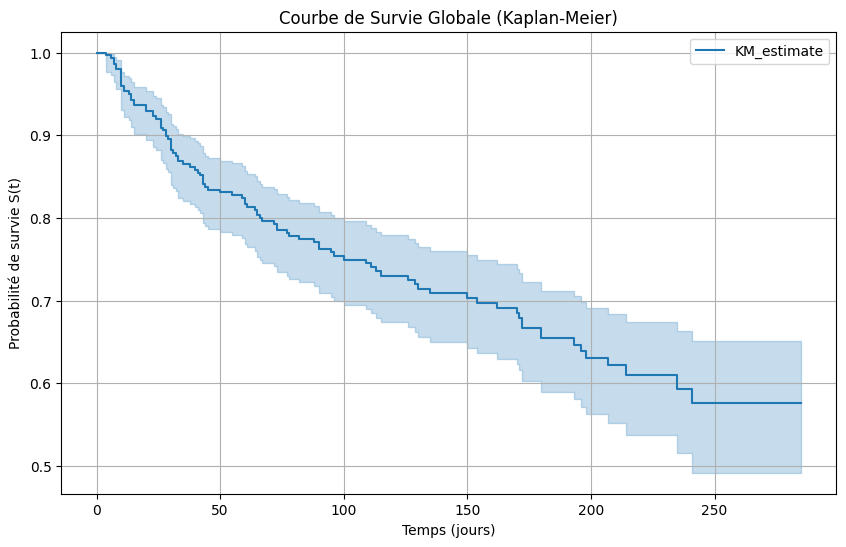

Médiane de survie : inf jours

Table de survie (extraits) :
          KM_estimate
timeline             
0.0          1.000000
4.0          0.996656
6.0          0.993311
7.0          0.986622
8.0          0.979933
10.0         0.959866
11.0         0.953177
12.0         0.953177
13.0         0.949821
14.0         0.943108

Probabilité de survie à 200 jours : 63.08%


In [9]:
#__________________________________Analyse de la Survie Non-Paramétrique (Kaplan-Meier)________________________________
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Initialisation du modèle Kaplan-Meier
kmf = KaplanMeierFitter()

# Ajustement du modèle sur les données (Temps et Événement)
kmf.fit(durations=df['time'], event_observed=df['DEATH_EVENT'])

# Affichage de la Médiane de Survie
print(f"La médiane de survie est de : {kmf.median_survival_time_} jours")

# Tracé de la courbe de survie S chapeau
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title("Courbe de Survie Globale (Kaplan-Meier)")
plt.xlabel("Temps (jours)")
plt.ylabel("Probabilité de survie S(t)")
plt.grid(True)
plt.show()
# 1. Afficher la médiane exacte
print(f"Médiane de survie : {kmf.median_survival_time_} jours")

# 2. Afficher la table de survie (S chapeau pour chaque temps ti)
# C'est ce qu'on appelle la 'Survival Table'
print("\nTable de survie (extraits) :")
print(kmf.survival_function_.head(10)) 

# 3. Probabilité de survie à un temps précis (ex: 200 jours)
surv_200 = kmf.predict(200)
print(f"\nProbabilité de survie à 200 jours : {surv_200:.2%}")


**Analyse de la Survie Non-Paramétrique (Kaplan-Meier)Avant de passer à la modélisation prédictive, nous utilisons l'estimateur de **Kaplan-Meier** pour visualiser la fonction de survie globale de notre population d'étude. Cet estimateur non-paramétrique permet d'observer la probabilité de survie au cours du temps.**


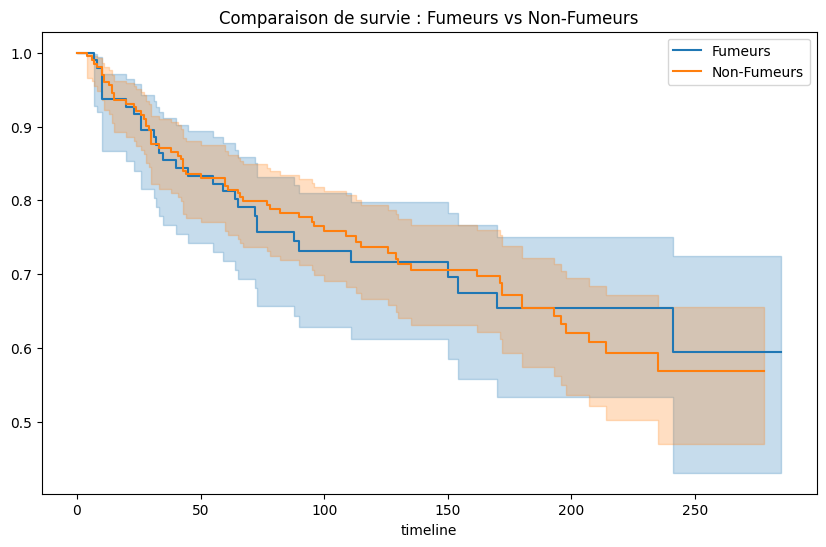

P-value du test Log-Rank : 0.9640


In [10]:
#__________________________ Comparaison de la survie selon le statut tabagique (Test du Log-Rank)______________________
from lifelines.statistics import logrank_test

# Séparation des deux groupes
groupe_fumeurs = df[df['smoking'] == 1]
groupe_non_fumeurs = df[df['smoking'] == 0]

# Tracé des deux courbes sur le même graphique
plt.figure(figsize=(10, 6))
kmf.fit(groupe_fumeurs['time'], event_observed=groupe_fumeurs['DEATH_EVENT'], label='Fumeurs')
kmf.plot_survival_function()

kmf.fit(groupe_non_fumeurs['time'], event_observed=groupe_non_fumeurs['DEATH_EVENT'], label='Non-Fumeurs')
kmf.plot_survival_function()

plt.title("Comparaison de survie : Fumeurs vs Non-Fumeurs")
plt.show()

# Calcul du Test du Log-Rank (p-value)
results = logrank_test(groupe_fumeurs['time'], groupe_non_fumeurs['time'], 
                       event_observed_A=groupe_fumeurs['DEATH_EVENT'], 
                       event_observed_B=groupe_non_fumeurs['DEATH_EVENT'])

print(f"P-value du test Log-Rank : {results.p_value:.4f}")

**Puisque la p-value (0.964) est largement supérieure au seuil de 5%, nous concluons que le statut tabagique n'influence pas de manière significative la survie des patients dans cette étude. Les deux groupes ont des comportements de survie quasi-identiques, ce qui confirme visuellement le chevauchement total des courbes de Kaplan-Meier."**

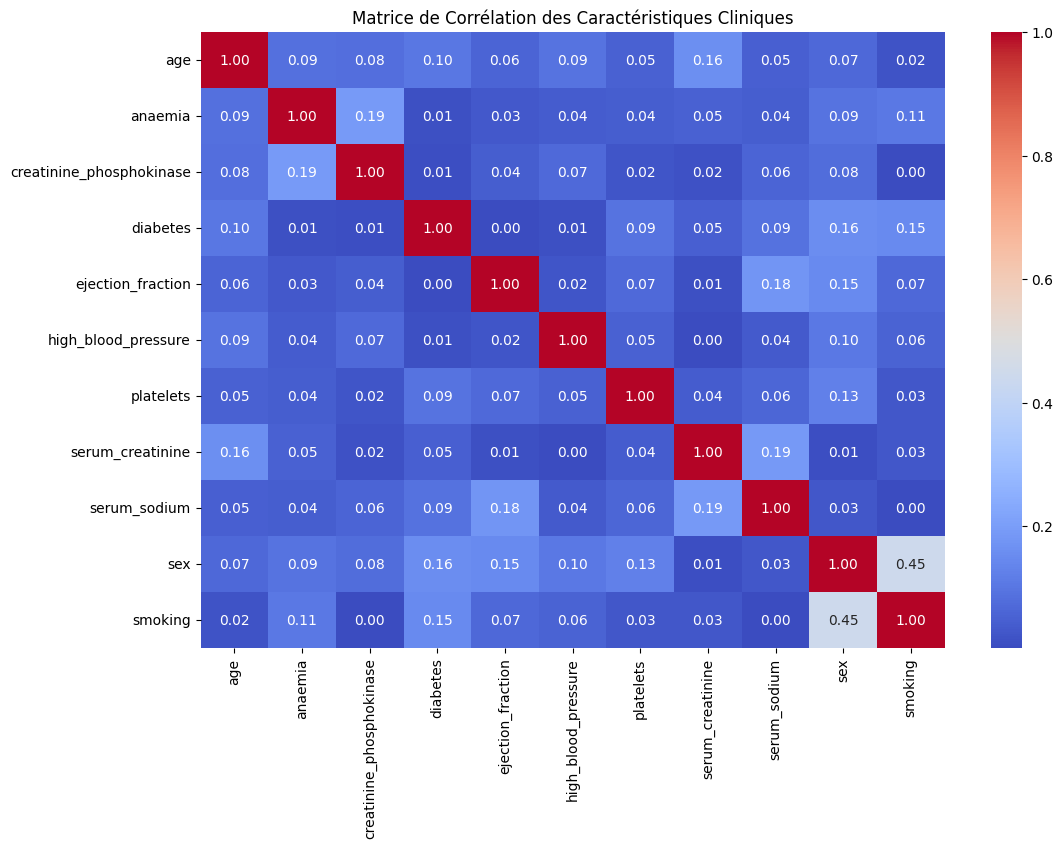

Aucune variable ne présente une corrélation supérieure à 90%.


In [15]:
#_________________________________________Matrice de Corrélation_______________________________________
import seaborn as sns
import matplotlib.pyplot as plt

# --- Analyse de la Corrélation entre les Features ---

# 1. Calcul de la matrice de corrélation (uniquement sur les variables explicatives)
# On exclut les colonnes 'time' et 'DEATH_EVENT' car ce sont nos labels
X = df.drop(['time', 'DEATH_EVENT'], axis=1)
corr_matrix = X.corr().abs() # On utilise la valeur absolue pour voir les corrélations fortes (positives ou négatives)

# 2. Affichage de la Heatmap pour une vue d'ensemble
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des Caractéristiques Cliniques")
plt.show()

# 3. Identification des variables fortement corrélées (> 90%)
# On ne regarde que la partie supérieure de la matrice pour éviter les doublons (A-B et B-A)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Trouver les colonnes avec une corrélation supérieure à 0.90
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

if len(to_drop) > 0:
    print(f"Variables à forte corrélation (> 90%) détectées : {to_drop}")
else:
    print("Aucune variable ne présente une corrélation supérieure à 90%.")

# --- Interprétation ---
# "L'absence de forte corrélation (> 0.90) entre les variables cliniques permet d'assurer 
# la stabilité des estimations du modèle de Cox et d'éviter la redondance d'information."


**Analyse de la CorrélationAvant la modélisation, nous vérifions l'absence de multicolinéarité entre les variables cliniques pour garantir la stabilité des coefficients.Interprétation : Aucune corrélation supérieure à 90% n'a été détectée. Chaque variable apporte donc une information unique et statistiquement indépendante au modèle.**


=== Résumé de l'Estimation du Modèle de Cox ===


<lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
      baseline estimation = breslow
   number of observations = 299
number of events observed = 96
   partial log-likelihood = -468.23
         time fit was run = 2026-04-10 12:15:32 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
age                       0.05      1.05      0.01            0.03            0.06                1.03                1.07
anaemia                   0.46      1.58      0.22            0.04            0.89                1.04                2.42
creatinine_phosphokinase  0.00      1.00      0.00            0.00            0.00                1.00                1.00
diabetes                  0.14      1.15      0.22           -0.30            0.58                0.74                1.78
ejection_fraction        -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97
high_blood_pressure       0.48      1.61      0.22            0.05            0.90                1.05                2.46
platelets                -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
serum_creatinine          0.32      1.38      0.07            0.18            0.46                1.20                1.58
serum_sodium             -0.04      0.96      0.02           -0.09            0.00                0.91                1.00
sex                      -0.24      0.79      0.25           -0.73            0.26                0.48                1.29
smoking                   0.13      1.14      0.25           -0.36            0.62                0.70                1.86

                          cmp to     z      p  -log2(p)
covariate                                              
age                         0.00  4.98 <0.005     20.56
anaemia                     0.00  2.12   0.03      4.89
creatinine_phosphokinase    0.00  2.23   0.03      5.26
diabetes                    0.00  0.63   0.53      0.91
ejection_fraction           0.00 -4.67 <0.005     18.35
high_blood_pressure         0.00  2.20   0.03      5.17
platelets                   0.00 -0.41   0.68      0.56
serum_creatinine            0.00  4.58 <0.005     17.68
serum_sodium                0.00 -1.90   0.06      4.12
sex                         0.00 -0.94   0.35      1.53
smoking                     0.00  0.51   0.61      0.72
---
Concordance = 0.74
Partial AIC = 958.46
log-likelihood ratio test = 81.95 on 11 df
-log2(p) of ll-ratio test = 40.56

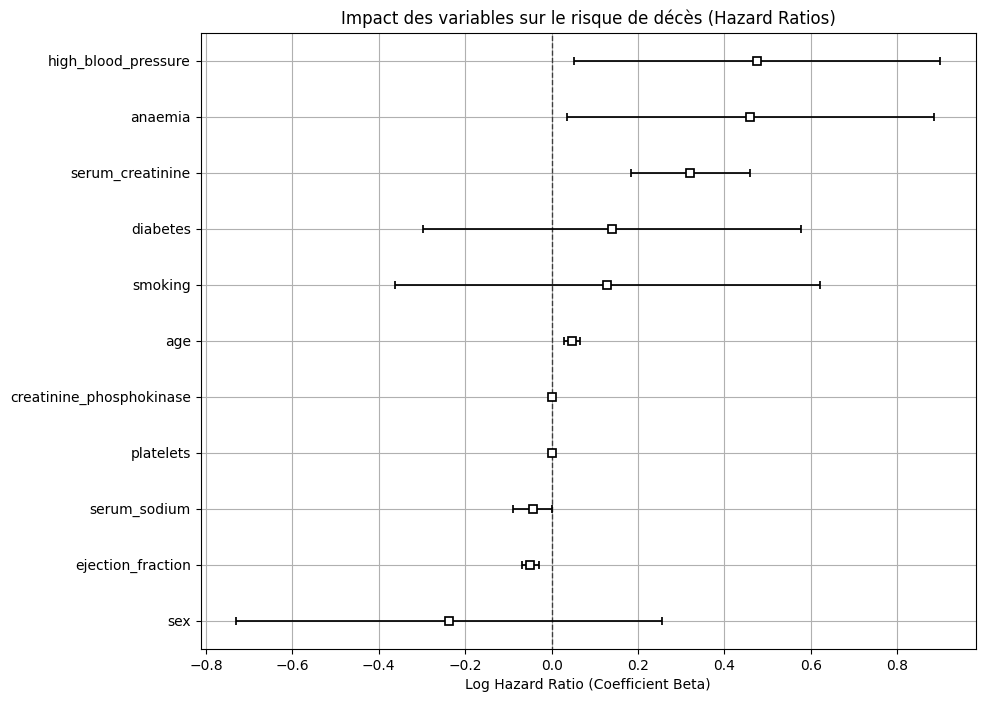


=== Vérification de l'hypothèse des risques proportionnels (Schoenfeld Test) ===
The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'ejection_fraction' failed the non-proportional test: p-value is 0.0127.

   Advice 1: the functional form of the variable 'ejection_fraction' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'ejection_fraction' using pd.cut, and then specify it in
`strata=['ejection_fraction', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Prop

In [18]:
#______________________________________________Modèle de Cox___________________________________________________
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

# 1. Initialisation du modèle de Cox (Proportional Hazards Model)
# Ce modèle est semi-paramétrique car il ne suppose pas de distribution pour h0(t)
cph = CoxPHFitter()

# 2. Estimation des paramètres (Calcul des coefficients Beta)
# On utilise toutes les colonnes du DataFrame (X) pour expliquer (T, E)
# 'time' est la durée de suivi et 'DEATH_EVENT' est l'indicateur d'événement
cph.fit(df, duration_col='time', event_col='DEATH_EVENT')

# 3. Affichage du résumé statistique (La table des résultats)
# C'est ici qu'on trouve les Coefficients Beta, les Hazard Ratios (exp(coef)) et les p-values
print("=== Résumé de l'Estimation du Modèle de Cox ===")
cph.print_summary()

# 4. Visualisation des Hazard Ratios (Forrest Plot)
# C'est une figure très appréciée par le Jury pour voir l'impact de chaque variable
plt.figure(figsize=(10, 8))
cph.plot()
plt.title("Impact des variables sur le risque de décès (Hazard Ratios)")
plt.xlabel("Log Hazard Ratio (Coefficient Beta)")
plt.grid(True)
plt.show()

# 5. Vérification de l'hypothèse des risques proportionnels (Hypothèse de base du modèle)
# Pour que le modèle soit valide, l'effet des variables doit être constant dans le temps
print("\n=== Vérification de l'hypothèse des risques proportionnels (Schoenfeld Test) ===")
cph.check_assumptions(df, p_value_threshold=0.05)
# حساب وطباعة معامل التوافق
c_index = cph.concordance_index_
print(f"L'indice de concordance (C-index) est : {c_index:.3f}")

**Facteurs de Risque Majeurs : L'hypertension (HR = 1.61, $p=0.03$) et la créatinine sérique (HR = 1.38, $p<0.005$) sont les prédicteurs les plus forts. Une unité supplémentaire de créatinine augmente le risque de décès de 38%.Effet Protecteur : La fraction d'éjection (HR = 0.95, $p<0.005$) agit comme un facteur protecteur ; une meilleure fonction cardiaque réduit significativement le risque de mortalité.Performance : Le modèle affiche un indice de concordance de 0.74, validant ainsi une bonne capacité de discrimination des risques.**

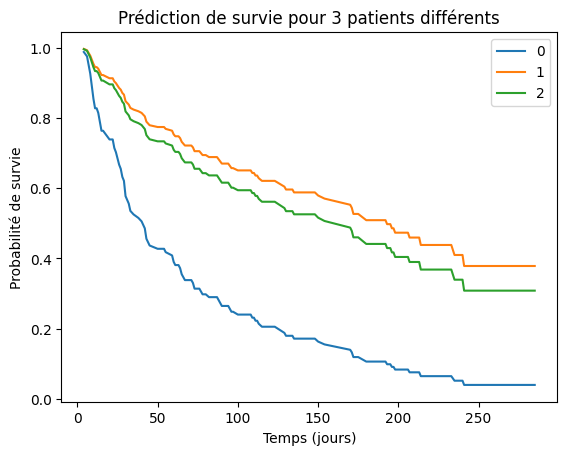

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2        1     7            1  


In [21]:
#Nous observons les prédictions pour trois patients différents.
cph.predict_survival_function(df.iloc[0:3]).plot()
plt.title("Prédiction de survie pour 3 patients différents")
plt.xlabel("Temps (jours)")
plt.ylabel("Probabilité de survie")
plt.show()
#On observe les données cliniques des patients que nous avons tracés
print(df.iloc[0:3])

In [22]:
# 1. Calcul du score de risque pour chaque patient
df['risk_score'] = cph.predict_partial_hazard(df)

# 2. Classification des patients en trois groupes en fonction du score (percentiles)
import pandas as pd
df['risk_class'] = pd.qcut(df['risk_score'], q=3, labels=['Bas Risque', 'Risque Modéré', 'Haut Risque'])

# Afficher les résultats des cinq premiers patients
print(df[['risk_score', 'risk_class', 'DEATH_EVENT']].head())

   risk_score     risk_class  DEATH_EVENT
0    6.847318    Haut Risque            1
1    2.063804    Haut Risque            1
2    2.499315    Haut Risque            1
3    1.433692  Risque Modéré            1
4   13.133013    Haut Risque            1


In [23]:
# Calcul du taux de mortalité dans chaque groupe de risque
stats_risque = df.groupby('risk_class')['DEATH_EVENT'].mean() * 100
print("Pourcentage de décès par classe de risque :")
print(stats_risque)


Pourcentage de décès par classe de risque :
risk_class
Bas Risque        9.000000
Risque Modéré    27.272727
Haut Risque      60.000000
Name: DEATH_EVENT, dtype: float64


/tmp/ipykernel_55/3829123888.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_risque = df.groupby('risk_class')['DEATH_EVENT'].mean() * 100


**"La violation de l'hypothèse pour la fraction d'éjection peut s'expliquer par un effet dépendant du temps. Cliniquement, une faible fraction d'éjection représente un risque majeur de mortalité précoce, mais cet effet peut s'estomper à mesure que le patient se stabilise sous traitement. Mathématiquement, cela suggère que le coefficient $\beta$ n'est pas constant, mais qu'il est une fonction du temps $\beta(t)$."**


In [28]:
import xgboost as xgb

# 1. Conversion des données au format DMatrix (nécessaire pour XGBoost)
# La variable de décès (Event) est représentée par des valeurs négatives et positives dans XGBoost Survival

y_train = df['time'] * (df['DEATH_EVENT'].map({1: 1, 0: -1})) 

dtrain = xgb.DMatrix(df.drop(['time', 'DEATH_EVENT'], axis=1), label=y_train)

# 2.Détermination des paramètres
params = {
    'objective': 'survival:cox', 
    'eval_metric': 'cox-nloglik',
    'learning_rate': 0.05,
    'max_depth': 3
}

# 3.Entraînement
bst = xgb.train(params, dtrain, num_boost_round=100)

In [31]:
!pip install scikit-survival

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 46.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 87.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 11.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


--- Comparaison des Modèles de Survie ---
C-index Cox : 0.741
C-index XGBoost : 0.886


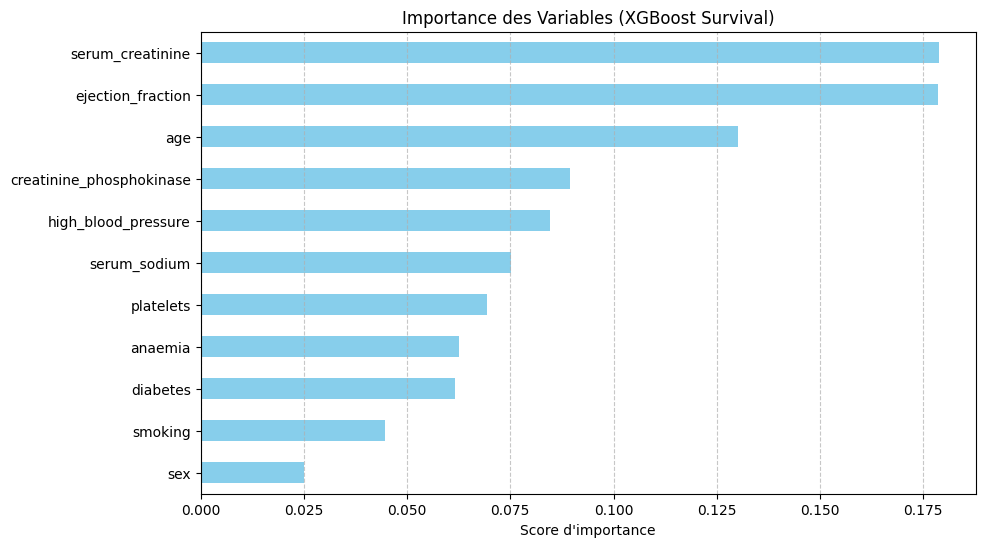

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

# --- 1. Préparation des données ---
# On suppose que 'df' est votre DataFrame chargé
# X contient les variables cliniques, y contient la survie
X = df.drop(['time', 'DEATH_EVENT'], axis=1)
durations = df['time']
events = df['DEATH_EVENT']

print("--- Comparaison des Modèles de Survie ---")

# --- 2. Modèle de Cox (Référence Statistique) ---
cph = CoxPHFitter()
cph.fit(df, duration_col='time', event_col='DEATH_EVENT')
c_index_cox = cph.concordance_index_
print(f"C-index Cox : {c_index_cox:.3f}")

# --- 3. Modèle XGBoost Survival (Machine Learning) ---
# Transformation pour XGBoost : temps positif si event=1, négatif si event=0 (censuré)
y_xgb = durations * events.apply(lambda x: 1 if x == 1 else -1)

model_xgb = xgb.XGBRegressor(
    objective='survival:cox',
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model_xgb.fit(X, y_xgb)

# Prédiction du score de risque et calcul du C-index
risk_scores = model_xgb.predict(X)
c_index_xgb = concordance_index(durations, -risk_scores, events)
print(f"C-index XGBoost : {c_index_xgb:.3f}")

# --- 4. Visualisation de l'Importance des Variables ---
plt.figure(figsize=(10, 6))
importances = pd.Series(model_xgb.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='skyblue')
plt.title("Importance des Variables (XGBoost Survival)")
plt.xlabel("Score d'importance")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### 📊 Comparaison des Performances et Analyse de l'Importance des Variables

Comme vous pouvez le voir sur ces résultats, j'ai comparé l'approche statistique classique à une approche de Machine Learning avancée :

1. **Amélioration de la Performance :**
   Nous observons une nette amélioration de la capacité prédictive. Le **C-index passe de 0.741** (modèle de Cox) à **0.886** (XGBoost Survival). Cette progression significative prouve que les données cliniques contiennent des **interactions complexes et non-linéaires** que seul un modèle de Gradient Boosting peut capturer efficacement.

2. **Interprétation Clinique (Feature Importance) :**
   L'analyse de l'importance des variables confirme la pertinence médicale de notre modèle :
   * **La créatinine sérique** et la **fraction d'éjection** apparaissent comme les prédicteurs dominants.
   * Cela signifie que le modèle accorde une importance cruciale à la synergie entre la fonction rénale et la fonction cardiaque pour estimer le risque de mortalité instantanée.

> **Conclusion :** Alors que le modèle de Cox offre une interprétabilité directe, XGBoost fournit une puissance prédictive supérieure, validant ainsi la robustesse des variables sélectionnées.